# CONFIG

In [2]:
import os
import pandas as pd
import numpy as np

from maikol_utils.print_utils import print_separator


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
from src.config.config import Configuration

CONFIG = Configuration()

# CODE

## Data

In [4]:
from maikol_utils.file_utils import list_dir_files

rng = np.random.default_rng(CONFIG.seed)

files, n = list_dir_files(CONFIG.all_path, recursive=True)
print(f"Found {n} files in {CONFIG.all_path}")

files = rng.choice(files, size=CONFIG.max_files, replace=False)
print(f"Selected {len(files)} files for processing.")


Found 6899 files in data/NaturalImages/all
Selected 100 files for processing.


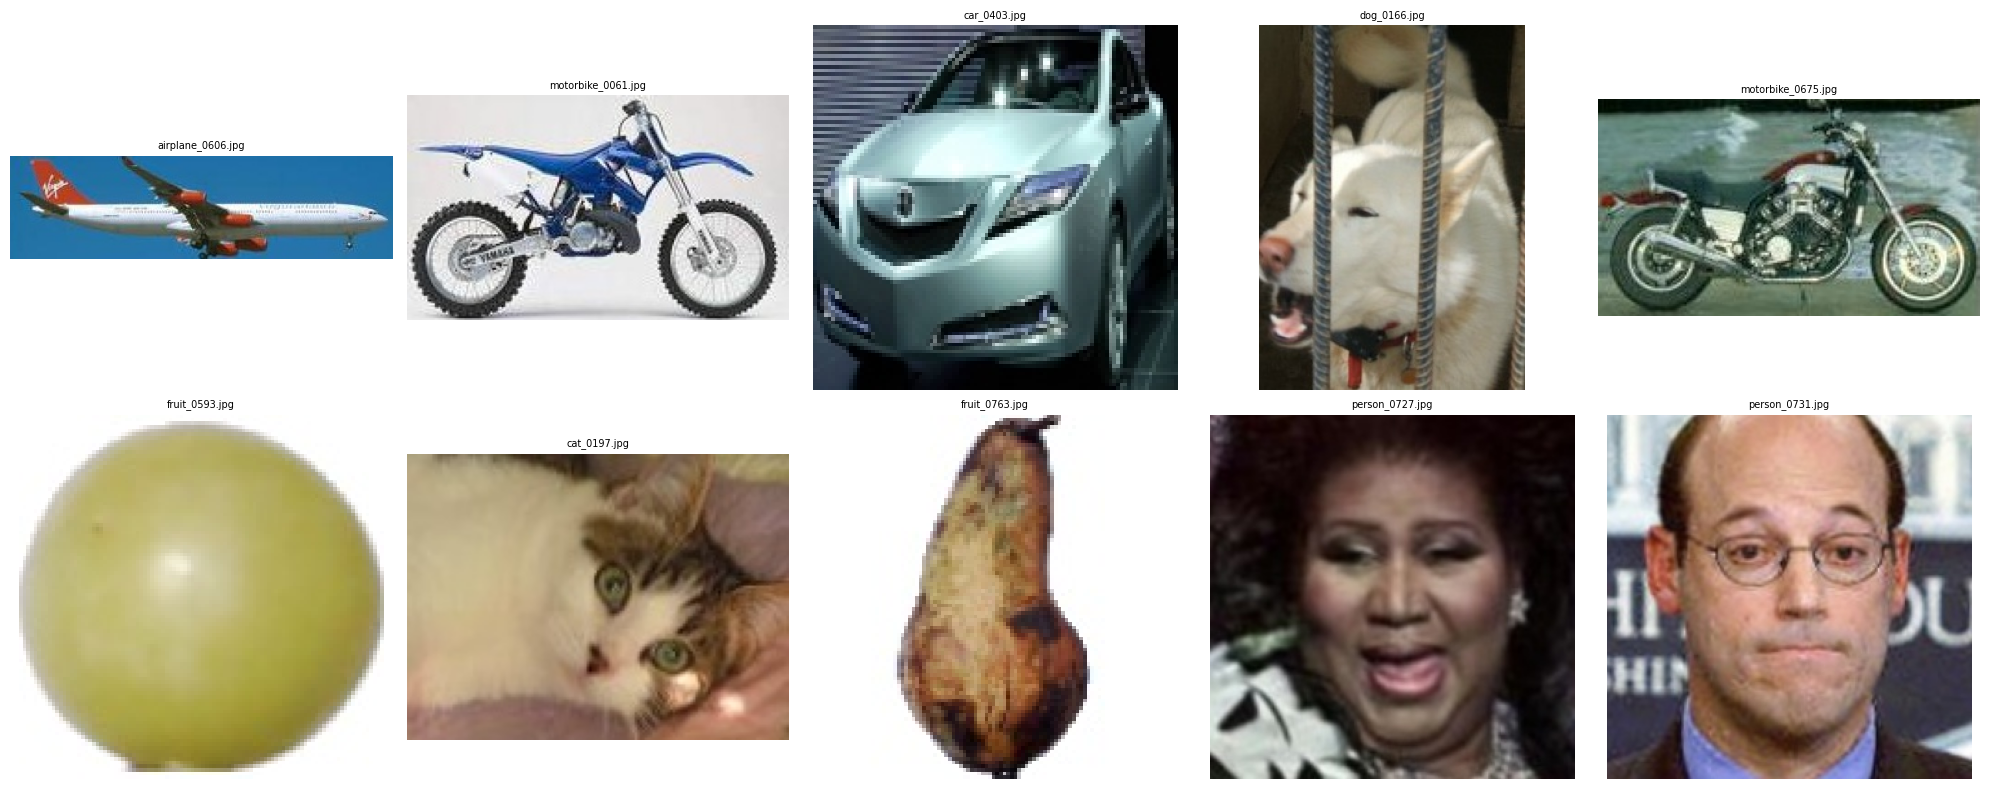

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

rng = np.random.default_rng(CONFIG.seed)
sample = rng.choice(files, size=10, replace=False)

def show_images(images):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, path in zip(axes.flatten(), images):
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(path), fontsize=7)

    plt.tight_layout()
    plt.show()

show_images(sample)


### Create partitions
- Convert all to jpg

In [6]:
from src.data import create_partition, apply_filter
# create_partition(CONFIG, rng)
# apply_filter(CONFIG)

Train: 5521 images
Val: 689 images
Test: 689 images
________________________________________________________________
                  data/NaturalImages/img_train                  



Copying data/NaturalImages/img_train images: 100%|██████████| 5521/5521 [00:01<00:00, 2851.52it/s]


________________________________________________________________
                   data/NaturalImages/img_val                   



Copying data/NaturalImages/img_val images: 100%|██████████| 689/689 [00:00<00:00, 2811.32it/s]


________________________________________________________________
                  data/NaturalImages/img_test                   



img_train:   0%|          | 0/5521 [00:00<?, ?it/s]/home/turbotowerlnx/Documents/Master/BIOM/src/data/filter.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(sig < 1e-6, 0.0, (img.astype(np.float64) - mu) / sig)
img_test: 100%|██████████| 689/689 [00:01<00:00, 477.33it/s] 


## Get all image crops

In [7]:
import cv2

from src.data import get_all_image_crops
crops = get_all_image_crops(CONFIG, sample[0])
print(len(crops))
print(sample[0])



1080
data/NaturalImages/all/airplane/airplane_0606.jpg


In [8]:
import time

t1 = time.time()
all_crops_seq = [get_all_image_crops(CONFIG, img) for img in files]
t2 = time.time()
seq_time = t2 - t1

print(f"{seq_time:.2f}s  ({seq_time/len(files)*1000:.1f} ms/img)")

0.08s  (0.8 ms/img)


1080
[ 92 829  95 702 471 465 751 101 217 923]


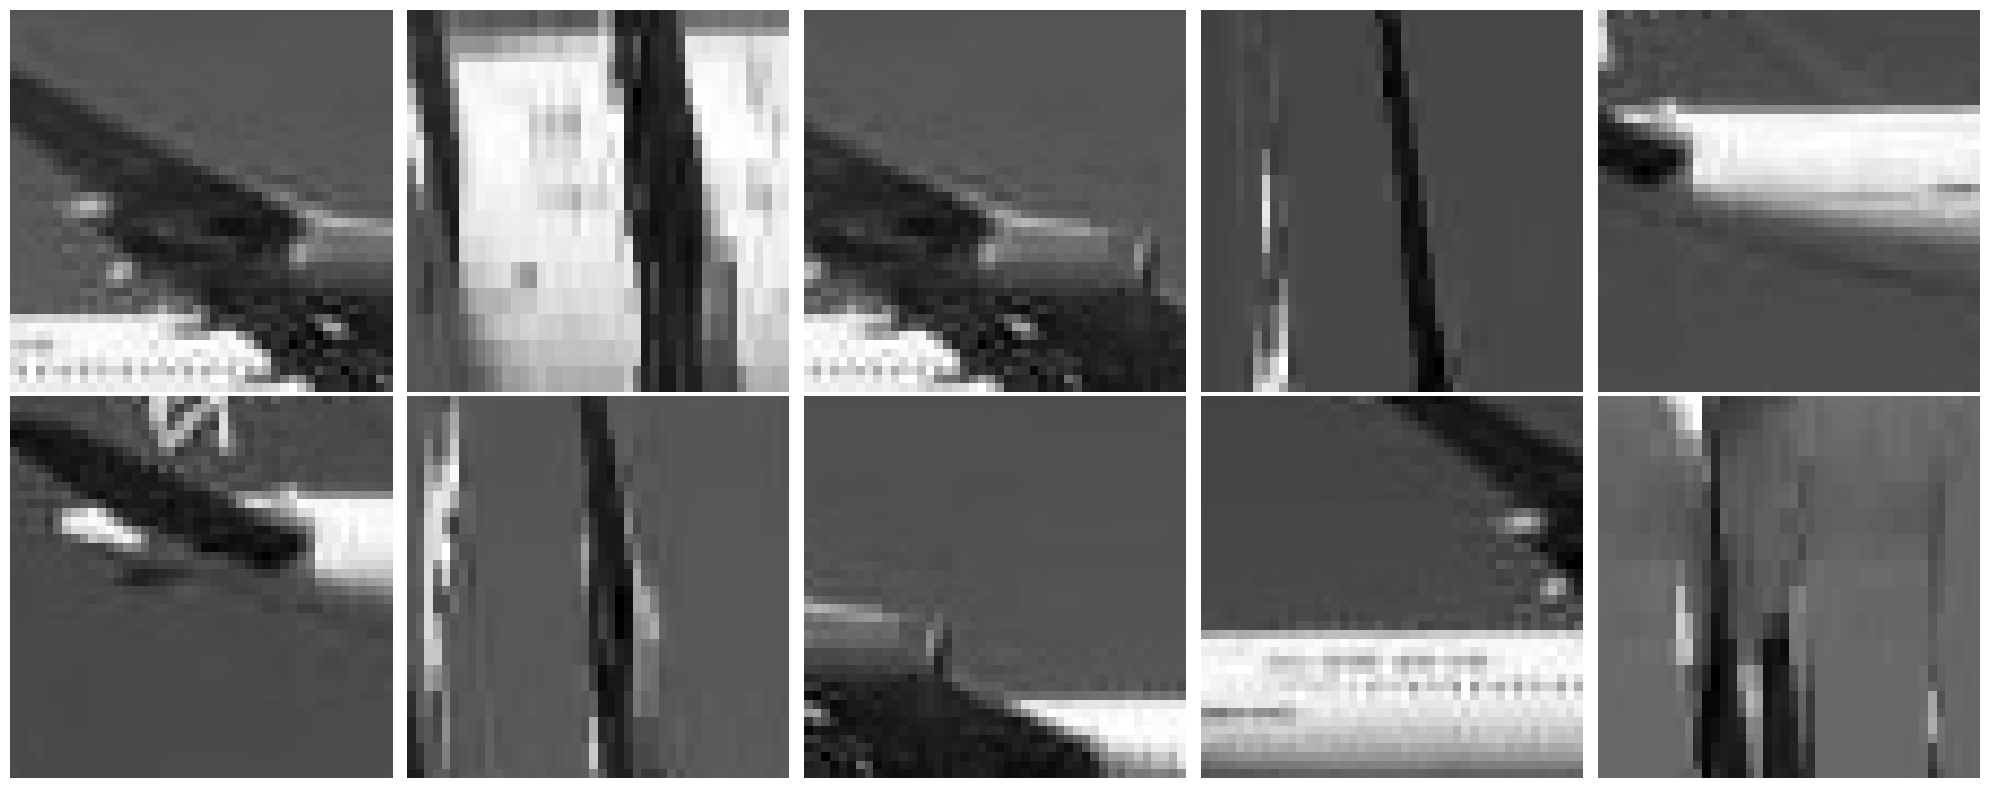

In [9]:
def show_crops(crops_to_show):
    n = len(crops_to_show)
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, crop in zip(axes, crops_to_show):
        # grayscale (2D) — show directly; BGR (3D uint8) — convert to RGB
        if crop.ndim == 2:
            ax.imshow(crop, cmap="gray")
        else:
            crop_show = crop
            if crop.dtype != np.uint8:
                crop_show = np.clip(crop, 0, 255).astype(np.uint8)
            ax.imshow(cv2.cvtColor(crop_show, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    for ax in axes[len(crops_to_show):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


print(len(crops))

rng = np.random.default_rng(CONFIG.seed)
k = min(10, len(crops))
idx = rng.choice(len(crops), size=k, replace=False)
print(idx)
sampled_crops = [crops[i] for i in idx]
show_crops(sampled_crops)


## Normalization

### Integral image

In [10]:
from src.data import get_integral_image, get_integral_squared_image, get_integral_sum

integral = get_integral_image(crops[1])
integral_2 = get_integral_squared_image(crops[1])
# print(integral)
# print(integral_2)

print(get_integral_sum(integral, 0, 0, 10, 10))
print(get_integral_sum(integral_2, 0, 0, 10, 10))


11104
1019284


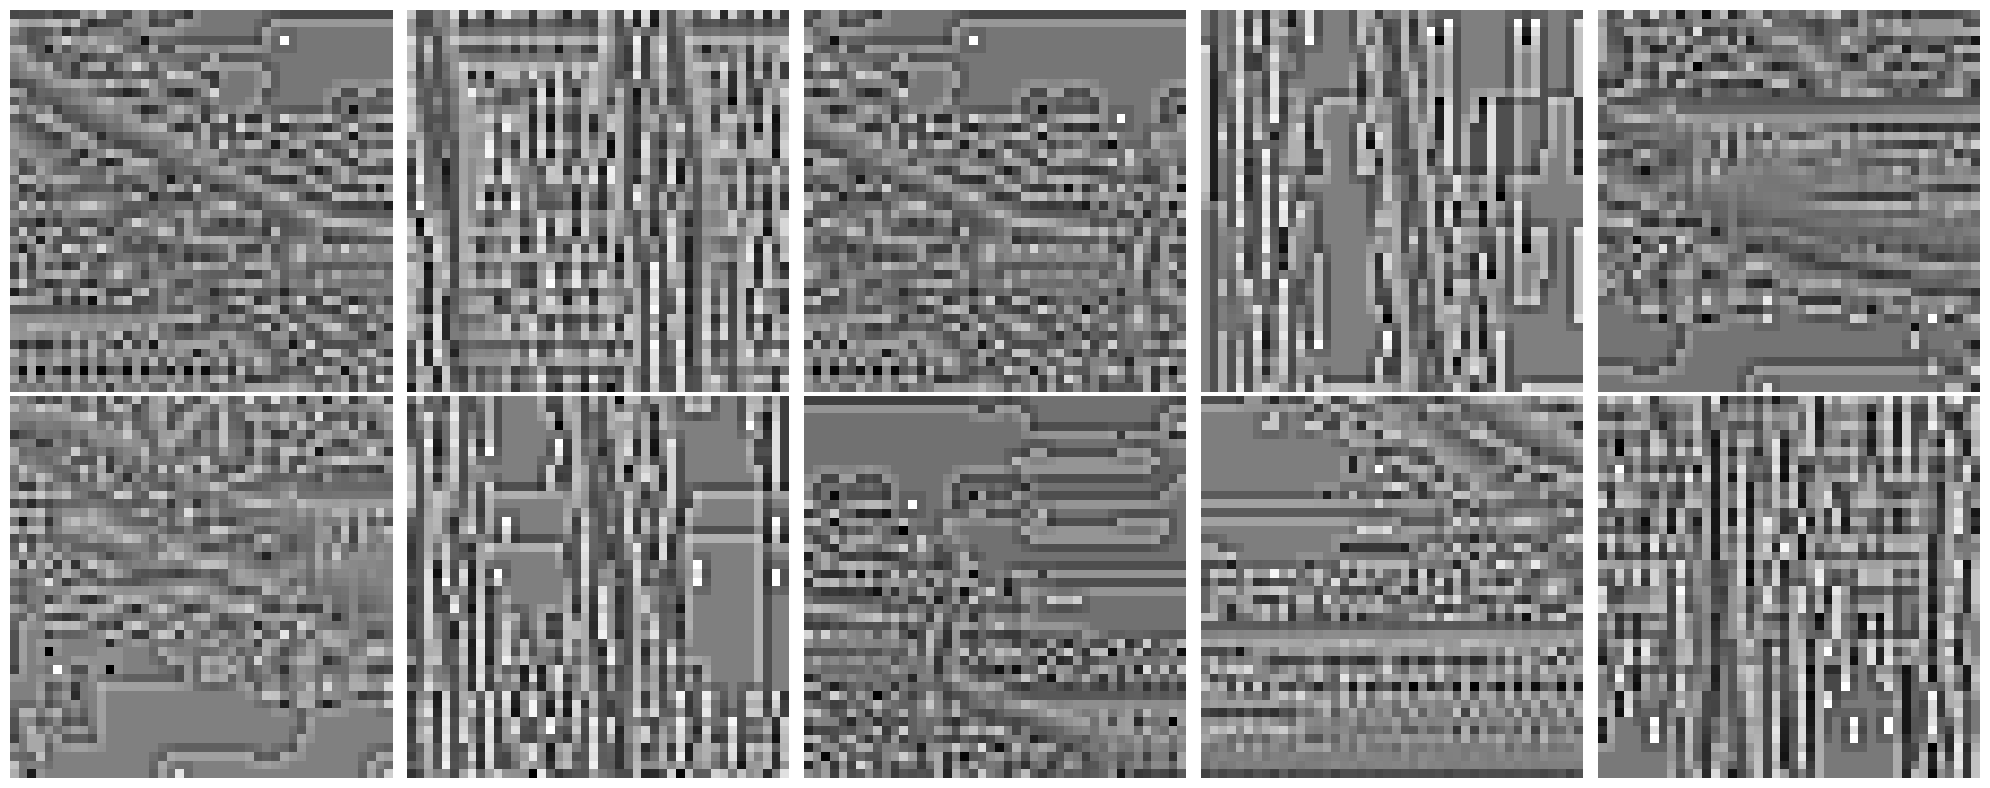

In [11]:
from src.data import local_normalize_image


rng = np.random.default_rng(CONFIG.seed)
k = min(10, len(crops))
idx = rng.choice(len(crops), size=k, replace=False)
sampled_crops = [local_normalize_image(CONFIG, crops[i]) for i in idx]
show_crops(sampled_crops)


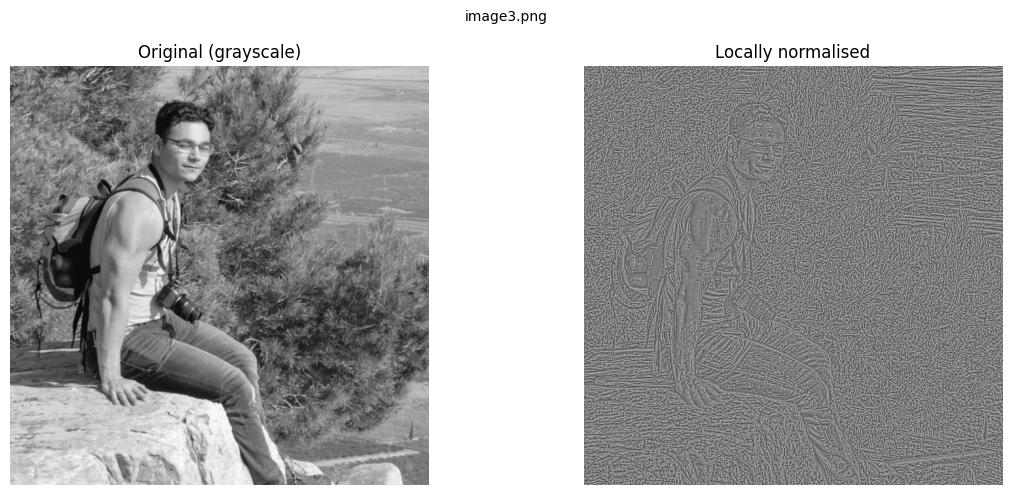

In [12]:

img_path = os.path.join("data", "image3.png")
img_bgr  = cv2.imread(img_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img_norm = local_normalize_image(CONFIG, img_gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")

axes[1].imshow(img_norm, cmap="gray")
axes[1].set_title("Locally normalised")
axes[1].axis("off")

plt.suptitle(os.path.basename(img_path), fontsize=10)
plt.tight_layout()
plt.show()


## Neural network

En el paper original usan una RN normal sin convoluciones, vamos a probar con y sin ellas

### Original and  Custom CNN

In [13]:
from src.model import RowleyFaceNN, FaceCNN

## Train

In [14]:
# from src.model import train_model
# from src.model import FaceDetectionModule, FaceDataModule


# data_module  = FaceDataModule(CONFIG)
# model_module = FaceDetectionModule(
#     CONFIG=CONFIG,
#     model=FaceCNN(
#         in_channels=1 if CONFIG.gray_scale else 3,
#         num_classes=1,
#     ),
# )

# train_model(
#     CONFIG, 
#     data_module,
#     model_module
# )

## Load trained model

In [27]:
from src.model import RowleyFaceNN, FaceCNN
from src.model import FaceDetectionModule, FaceDataModule

print("Loading:", CONFIG.best_cnn_model_path)

# path = CONFIG.best_cnn_model_path
path = os.path.join(CONFIG.MODELS_PATH, "best_cnn_model-v4.ckpt")
loaded_module = FaceDetectionModule.load_from_checkpoint(
    path,
    CONFIG=CONFIG,
    model=FaceCNN(
        in_channels=1 if CONFIG.gray_scale else 3,
        num_classes=1,
    ),
)
loaded_module.eval()
print("Model loaded successfully.")

Loading: models/best_cnn_model.ckpt
Model loaded successfully.


## Use model

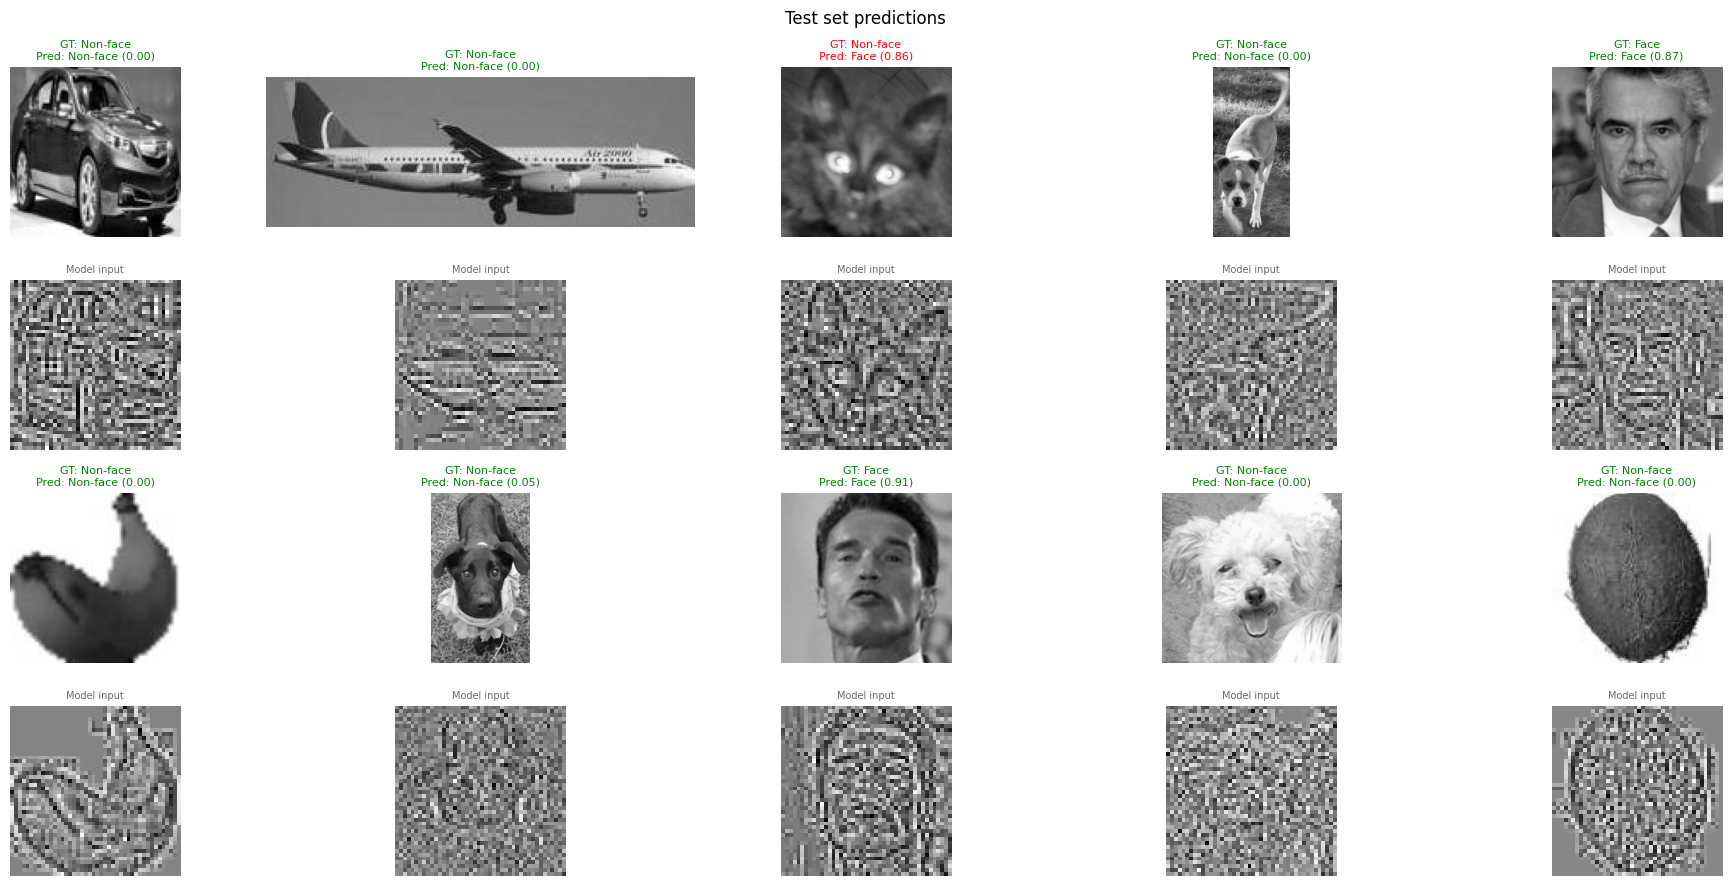

In [31]:
from maikol_utils.file_utils import list_dir_files
from src.data import local_normalize_image
import torchvision.transforms as transforms
import torch

test_paths, _ = list_dir_files(CONFIG.test_path)
# rng_inf = np.random.default_rng(CONFIG.seed+1)
# sample_paths = rng_inf.choice(test_paths, size=min(10, len(test_paths)), replace=False)
sample_paths = np.random.choice(test_paths, size=min(10, len(test_paths)), replace=False)

to_tensor = transforms.ToTensor()
device = next(loaded_module.parameters()).device

def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE if CONFIG.gray_scale else cv2.IMREAD_COLOR)
    if not CONFIG.gray_scale:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = local_normalize_image(CONFIG, img)
    
    # Rescale to [0, 255] — same as dataset.py
    img_min, img_max = img.min(), img.max() #-3, 3
    if img_max > img_min:
        img_uint8 = ((img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        img_uint8 = np.zeros_like(img_norm, dtype=np.uint8)
    img_resized = cv2.resize(img_uint8, (CONFIG.crop_size, CONFIG.crop_size), interpolation=cv2.INTER_AREA)
    tensor = to_tensor(Image.fromarray(img_resized))
    return tensor, img_resized

tensors, model_views = zip(*[preprocess(p) for p in sample_paths])

batch = torch.stack(tensors).to(device)
with torch.no_grad():
    # Model outputs raw logits — apply sigmoid to get probabilities in [0, 1]
    logits = loaded_module(batch).squeeze(1)
    probs = torch.sigmoid(logits).cpu().numpy()

# Layout: 5 images per logical row, 2 display rows each (original + model view)
n_imgs   = len(sample_paths)
cols     = min(5, n_imgs)
n_groups = int(np.ceil(n_imgs / cols))
n_rows   = n_groups * 2

fig, axes = plt.subplots(n_rows, cols, figsize=(4 * cols, 4.5 * n_groups))
axes = np.array(axes).reshape(n_rows, cols)

for i, (path, mv, prob) in enumerate(zip(sample_paths, model_views, probs)):
    grp_row  = i // cols
    col      = i  % cols
    orig_row = grp_row * 2
    view_row = grp_row * 2 + 1

    img_disp   = cv2.imread(path, cv2.IMREAD_GRAYSCALE if CONFIG.gray_scale else cv2.IMREAD_COLOR)
    gt_label   = "Face" if "person" in path else "Non-face"
    pred_label = "Face" if prob > 0.12 else "Non-face"
    correct    = gt_label == pred_label

    axes[orig_row, col].imshow(img_disp, cmap="gray" if CONFIG.gray_scale else None)
    axes[orig_row, col].set_title(f"GT: {gt_label}\nPred: {pred_label} ({prob:.2f})",
                                  color="green" if correct else "red", fontsize=8)
    axes[orig_row, col].axis("off")

    axes[view_row, col].imshow(mv, cmap="gray" if CONFIG.gray_scale else None)
    axes[view_row, col].set_title("Model input", fontsize=7, color="dimgray")
    axes[view_row, col].axis("off")

for col in range(n_imgs % cols or cols, cols):
    axes[n_rows - 2, col].axis("off")
    axes[n_rows - 1, col].axis("off")

plt.suptitle("Test set predictions", fontsize=12)
plt.tight_layout()
plt.show()


# Draw bounding boxes

In [ ]:
# [(x, y, w, h), ...]

faces = [(10, 20, 50, 50), (100, 150, 60, 60)]

In [ ]:
def draw_boxes(img, faces):
    for (x, y, w, h) in faces:
        # img, pt1, pt2, color (BGR), thickness
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return img
# 

boxes = draw_boxes(img_gray.copy(), faces)

cv2.imshow('Face Detection Result', boxes)
cv2.waitKey(0) 
cv2.destroyAllWindows()